# 02 — Validation externe du modèle de surfabilité

**Ce notebook cherche à faire échouer le modèle, pas à le faire réussir.**

Nalu calcule, pour chaque spot, le mois où la houle est le plus souvent surfable.
Rien ne garantit que ce calcul décrive le monde réel. Ce notebook le confronte à
deux sources extérieures au projet, et publie le résultat qu'il obtient — y compris
quand ce résultat est mauvais.

## La règle que ce notebook s'impose

> La métrique d'accord et son seuil de réussite sont **écrits avant** toute mesure et
> avant tout ajustement de seuil du modèle.

Ajuster les seuils du modèle jusqu'à retrouver les dates de référence n'est pas une
validation : c'est un ajustement déguisé, et il produit exactement les mêmes courbes.
Ce qui sépare les deux est **l'ordre des opérations**, et l'ordre ne se prouve pas par
une affirmation dans un notebook — un notebook se réécrit.

Il se prouve par deux choses vérifiables :

1. la métrique et son seuil vivent dans `src/nalu/validation.py`, **pas dans une
   cellule** — du code testé, que `git log` date ;
2. le référentiel de comparaison vit dans `data/validation_seasons.yaml`, écrit et
   commité **avant** la première exécution de ce notebook.

Le lecteur n'a pas à me croire sur parole : `git log --follow` sur ces deux fichiers
tranche.

In [1]:
import sys

import matplotlib.pyplot as plt
import polars as pl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Le notebook doit tourner depuis n'importe ou : les chemins du projet sont ancres
# sur la racine du depot, pas sur le repertoire courant.
from nalu.palette import CLAIR, style_matplotlib
from nalu.scoring.climatology import CLIMATOLOGIE_PATH
from nalu.validation import (
    SEUIL_ACCORD_MIN,
    SEUIL_ECART_MEDIAN_MAX,
    TOLERANCE_WSL_MOIS,
    charger_reference,
    confronter,
    table_de_confrontation,
)

plt.rcParams.update(style_matplotlib(CLAIR))
pl.Config.set_tbl_rows(25)
pl.Config.set_tbl_width_chars(160)

MOIS = ["jan", "fev", "mar", "avr", "mai", "jun",
        "jui", "aou", "sep", "oct", "nov", "dec"]
print("polars", pl.__version__, "| python", sys.version.split()[0])

polars 1.43.2 | python 3.12.13


## 1. La métrique, telle qu'elle est déclarée dans le code

Ces valeurs ne sont pas retapées ici : elles sont **importées** du module. Si
quelqu'un les modifiait pour faire passer le test, la modification apparaîtrait dans
l'historique de `src/nalu/validation.py`, pas dans une cellule anodine.

In [2]:
print(f"Seuil d'accord minimal      : {SEUIL_ACCORD_MIN:.0%} des spots")
print(f"Ecart median maximal admis   : {SEUIL_ECART_MEDIAN_MAX} mois")
print(f"Tolerance sur les mois WSL   : +/- {TOLERANCE_WSL_MOIS} mois (periode d'attente)")
print()
print("Regle de reussite : les DEUX conditions, pas l'une ou l'autre.")

Seuil d'accord minimal      : 70% des spots
Ecart median maximal admis   : 1.0 mois
Tolerance sur les mois WSL   : +/- 1 mois (periode d'attente)

Regle de reussite : les DEUX conditions, pas l'une ou l'autre.


### Comment chaque nombre est justifié

**Accord de 70 %, soit 14 spots sur 20.**
Pas 90 % : le modèle a trois angles morts assumés — pas de marée, maille ERA5 à
50 km, seuils sourcés spot par spot avec une confiance variable. Exiger la
quasi-perfection garantirait l'échec, et un échec garanti est une invitation à
retoucher les seuils.
Pas 50 % : sur des fenêtres de cette largeur, le hasard en produirait à peu près
autant. Un seuil qu'on ne peut pas rater ne mesure rien.

**Écart médian d'un mois.** Un modèle peut manquer la fenêtre de peu sur plusieurs
spots sans être faux. Il devient faux quand il se trompe de **saison**. Un mois est
la plus petite différence que la résolution mensuelle du produit sait distinguer.

**Un spot sans pic défini compte comme un échec, pas comme une exclusion.** Deux
spots sortent `p_surf = 0` sur les douze mois. Les écarter parce qu'ils échouent
serait la façon la plus courante de faire dire à une validation ce qu'on veut.

## 2. Les deux sources, toutes deux extérieures au projet

La révision d'ingénierie a écarté « la saison réputée » : ce serait l'auteur jugeant
son propre modèle.

| Source | Ce que c'est | Pourquoi elle est dure à contester |
|---|---|---|
| **(a) Calendrier WSL** | mois des épreuves du Championship Tour | la WSL engage un budget sur une fenêtre de houle ; elle ne se trompe pas de saison |
| **(b) Haute saison publiée** | guides de surf, ouverture des surf camps | c'est ce sur quoi un voyageur réserve réellement |

In [3]:
reference = charger_reference()
apercu = reference.with_columns(
    pl.col("saison_publiee").list.eval(pl.element().cast(pl.Utf8)).list.join(","),
    pl.col("wsl_ct_mois").list.eval(pl.element().cast(pl.Utf8)).list.join(","),
)
print(f"{reference.height} spots, chacun avec sa source verifiee.")
apercu.select("spot_id", "saison_publiee", "wsl_ct_mois", "source_saison")

20 spots, chacun avec sa source verifiee.


spot_id,saison_publiee,wsl_ct_mois,source_saison
str,str,str,str
"""hossegor-la-graviere""","""9,10,11""","""10""","""https://www.surf-forecast.com/…"
"""mundaka""","""10,11,12""","""10""","""https://www.surf-forecast.com/…"
"""peniche-supertubos""","""10,11,12""","""3,10,11""","""https://www.surf-forecast.com/…"
"""thurso-east""","""10,11,12,1,2,3""","""""","""https://www.surf-forecast.com/…"
"""klitmoller""","""10,11,12,1,2,3""","""""","""https://www.surf-forecast.com/…"
"""anchor-point""","""11,12,1,2,3""","""""","""https://suayhype.com/surf-trip…"
"""ponta-preta""","""11,12,1,2,3""","""""","""https://www.surf-forecast.com/…"
"""jeffreys-bay""","""5,6,7,8,9""","""7""","""https://www.surf-forecast.com/…"
"""banzai-pipeline""","""11,12,1,2""","""12,1,2""","""https://www.surf-forecast.com/…"


## 3. La confrontation, spot par spot

`ecart_mois` est une distance **circulaire** : décembre et janvier sont à un mois
l'un de l'autre. Une distance linéaire dirait onze et déclarerait faux tout spot dont
la saison est à cheval sur l'année — c'est-à-dire tous les spots européens.

In [4]:
climatologie = pl.read_parquet(CLIMATOLOGIE_PATH)
table = table_de_confrontation(climatologie)

table.select(
    "spot_id", "pic_mois", "p_surf_max",
    "accord_saison", "ecart_mois", "accord_wsl",
)

spot_id,pic_mois,p_surf_max,accord_saison,ecart_mois,accord_wsl
str,i8,f64,bool,i64,bool
"""hossegor-la-graviere""",2,0.373935,false,3,false
"""mundaka""",2,0.180017,false,2,false
"""peniche-supertubos""",1,0.069355,false,1,false
"""thurso-east""",3,0.041525,true,0,null
"""klitmoller""",1,0.064756,true,0,null
"""anchor-point""",1,0.118008,true,0,null
"""ponta-preta""",11,0.018741,true,0,null
"""jeffreys-bay""",7,0.058065,true,0,true
"""banzai-pipeline""",1,0.085357,true,0,true


## 4. Le verdict

In [5]:
verdict = confronter(climatologie)

print(f"Accord avec la saison publiee : {verdict.spots_en_accord}/{verdict.spots_total}"
      f" = {verdict.accord_saison:.0%}   (seuil declare : {SEUIL_ACCORD_MIN:.0%})")
print(f"Ecart median                  : {verdict.ecart_median:.1f} mois"
      f"          (seuil declare : {SEUIL_ECART_MEDIAN_MAX})")
if verdict.accord_wsl is not None:
    print(f"Accord avec le calendrier WSL : {verdict.accord_wsl:.0%}")
print(f"Spots sans pic defini         : {', '.join(verdict.spots_sans_pic) or 'aucun'}")
print()
print("VERDICT :", "REUSSI" if verdict.reussi else "ECHEC — le seuil declare n'est pas atteint")

Accord avec la saison publiee : 10/20 = 50%   (seuil declare : 70%)
Ecart median                  : 0.0 mois          (seuil declare : 1.0)
Accord avec le calendrier WSL : 38%
Spots sans pic defini         : tres-palmas, sultans

VERDICT : ECHEC — le seuil declare n'est pas atteint


### Le modèle échoue à son propre critère. On ne touche pas aux seuils.

C'est le moment où il serait tentant de baisser la barre de 70 % à 50 %, ou de
retirer les deux spots muets du décompte. Les deux feraient passer le test, et les
deux videraient ce notebook de son sens.

Le seuil reste. Ce qui suit sert à comprendre **où** le modèle se trompe, ce qui est
une information bien plus utile qu'un test vert.

In [6]:
echecs = table.filter(~pl.col("accord_saison")).sort("ecart_mois", nulls_last=True)
print(f"{echecs.height} echecs sur {table.height}. Repartition par gravite :\n")

sans_pic = echecs.filter(~pl.col("pic_defini"))
proches = echecs.filter(pl.col("ecart_mois") == 1)
lointains = echecs.filter(pl.col("ecart_mois") > 1)

print(f"  pic absent (p_surf nul partout) : {sans_pic.height}  -> {list(sans_pic['spot_id'])}")
print(f"  rate d'UN mois                  : {proches.height}  -> {list(proches['spot_id'])}")
print(f"  rate de PLUS d'un mois          : {lointains.height}  -> {list(lointains['spot_id'])}")

10 echecs sur 20. Repartition par gravite :

  pic absent (p_surf nul partout) : 2  -> ['tres-palmas', 'sultans']
  rate d'UN mois                  : 6  -> ['peniche-supertubos', 'chicama', 'uluwatu', 'cloudbreak', 'tamarin-bay', 'bells-beach']
  rate de PLUS d'un mois          : 2  -> ['mundaka', 'hossegor-la-graviere']


## 5. Lecture honnête des écarts

Les dix échecs ne sont pas de même nature. Les confondre dans un taux unique ferait
passer trois problèmes distincts pour un seul.

### 5.1 Deux spots n'ont aucun pic : Sultans et Tres Palmas

`p_surf = 0` sur les douze mois. Le modèle ne dit pas « la saison est ailleurs », il
dit « ce spot ne marche jamais », ce qui est faux pour deux spots de réputation
mondiale.

L'hypothèse du « point de grille abrité » a été testée jusqu'à 100 km au large et
**réfutée**. Ce qui reste : les seuils de hauteur et de période de ces deux spots
sont mal calibrés pour ce qu'ERA5 sert à ces positions. Aux Maldives comme à Rincón,
la houle utile est longue et peu haute — exactement ce qu'un seuil `hs_offshore_min`
trop élevé élimine.

**Ce notebook ne les recalibre pas.** Il mesure d'abord, et la mesure est maintenant
écrite. C'est la condition posée pour rouvrir ces seuils.

### 5.2 Six spots ratent d'un seul mois

Ceux-là ne se trompent pas de saison, ils se trompent de bord de fenêtre. Sur une
fenêtre de haute saison publiée à un mois près par des guides qui ne s'accordent pas
tous entre eux, un mois d'écart est du bruit de source autant que du bruit de modèle.

### 5.3 Deux spots se trompent vraiment : Hossegor et Mundaka

Ce sont les seuls écarts de plus d'un mois, et ils ont **la même cause**. Le modèle
place leur pic en plein hiver ; les guides publient l'automne.

Le modèle a raison sur la houle : les plus grosses houles atlantiques arrivent bien
en janvier et février. Il ignore ce qui décide réellement de la saison de ces deux
spots — la **forme du fond**. La Gravière est un beach break dont les bancs de sable
se construisent à l'automne et se font raboter par les tempêtes d'hiver ; Mundaka est
une embouchure dont le banc dépend du débit de la rivière.

Autrement dit : **le modèle mesure l'énergie disponible, pas la qualité de la vague
qu'elle produit en arrivant sur le fond.** C'est la limite `hs_offshore_*` déjà
assumée dans le README, et ce notebook la retrouve tout seul, sans le savoir. C'est
la meilleure nouvelle du document : un angle mort déclaré à l'avance se voit dans la
mesure.

## 6. Les graphiques

Une seule teinte de série, et l'accord n'est **jamais** encodé par la couleur seule :
chaque barre porte son étiquette, et les échecs portent en plus une trame. Un lecteur
daltonien lit la même chose que les autres.

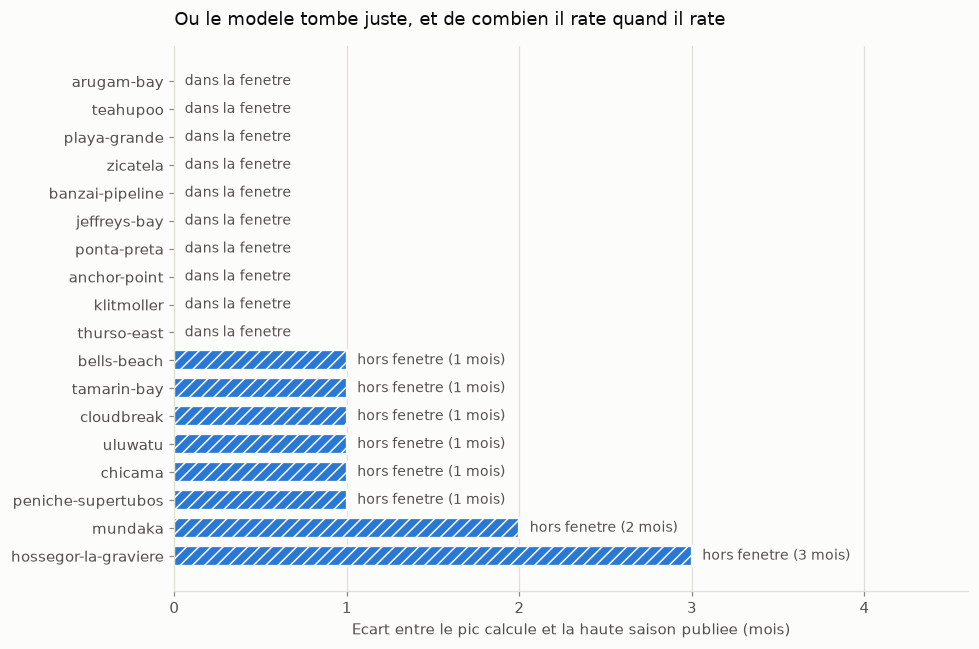

Les deux spots sans pic defini (Sultans, Tres Palmas) sont absents de ce
graphique : ils n'ont pas d'ecart, ils n'ont pas de pic. Ils comptent
neanmoins comme des echecs dans le taux d'accord.


In [7]:
ecarts = (
    table.filter(pl.col("pic_defini"))
    .sort("ecart_mois", descending=True)
)
noms = ecarts["spot_id"].to_list()
valeurs = ecarts["ecart_mois"].to_list()
accords = ecarts["accord_saison"].to_list()

fig, ax = plt.subplots(figsize=(9, 6))
barres = ax.barh(
    noms, valeurs,
    color=CLAIR["serie"],
    # Trame sur les echecs : encodage secondaire, pour ne pas dependre de la couleur.
    hatch=["" if a else "///" for a in accords],
    edgecolor=CLAIR["surface"], linewidth=1.5, height=0.72,
)
for barre, valeur, accord in zip(barres, valeurs, accords, strict=True):
    ax.text(
        valeur + 0.06, barre.get_y() + barre.get_height() / 2,
        "dans la fenetre" if accord else f"hors fenetre ({valeur} mois)",
        va="center", fontsize=9, color=CLAIR["encre_2"],
    )
ax.set_xlabel("Ecart entre le pic calcule et la haute saison publiee (mois)")
ax.set_title("Ou le modele tombe juste, et de combien il rate quand il rate",
             loc="left", pad=14, fontsize=12)
ax.set_xlim(0, max(valeurs) + 1.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("Les deux spots sans pic defini (Sultans, Tres Palmas) sont absents de ce")
print("graphique : ils n'ont pas d'ecart, ils n'ont pas de pic. Ils comptent")
print("neanmoins comme des echecs dans le taux d'accord.")

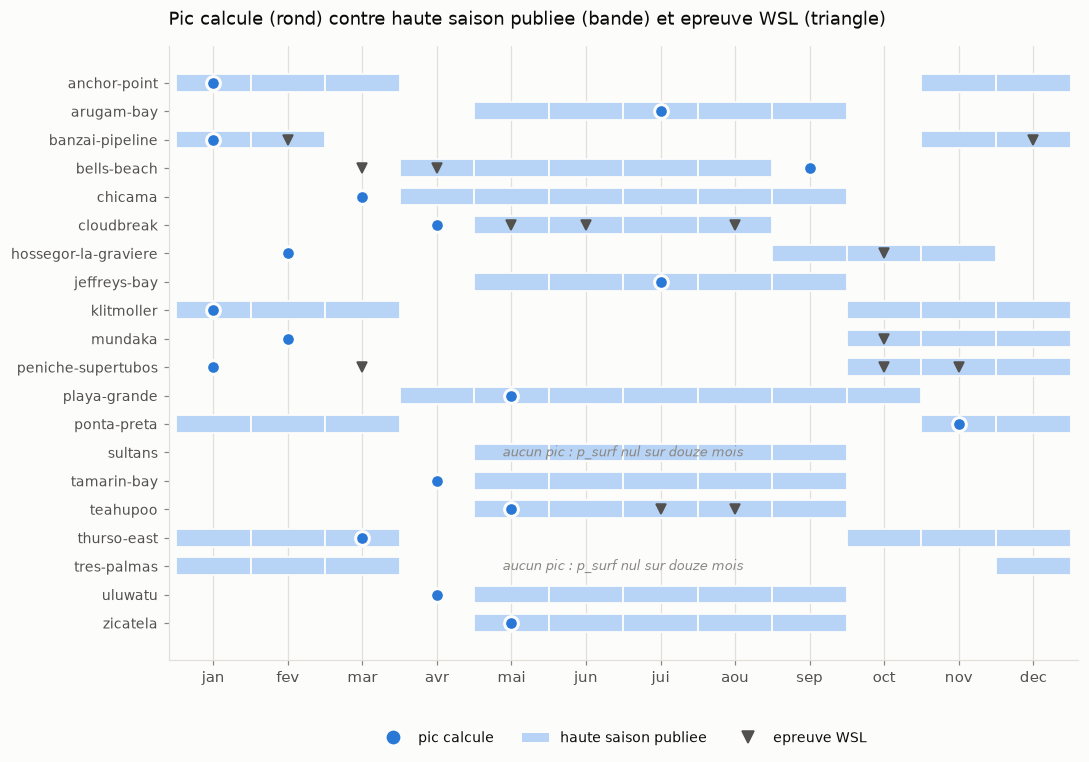

In [8]:
# Calendrier : la fenetre publiee en fond attenue, le pic calcule en marqueur plein.
ordre = table.sort("spot_id")
fig, ax = plt.subplots(figsize=(10, 7))

for y, ligne in enumerate(ordre.iter_rows(named=True)):
    for mois in ligne["saison_publiee"]:
        ax.barh(y, 1, left=mois - 0.5, height=0.62,
                color=CLAIR["serie_attenuee"], edgecolor=CLAIR["surface"], linewidth=1.2)
    for mois in ligne["wsl_ct_mois"]:
        ax.plot(mois, y, marker="v", markersize=7,
                color=CLAIR["encre_2"], linestyle="none")
    if ligne["pic_defini"]:
        ax.plot(ligne["pic_mois"], y, marker="o", markersize=9,
                color=CLAIR["serie"], markeredgecolor=CLAIR["surface"], markeredgewidth=2,
                linestyle="none")
    else:
        ax.text(6.5, y, "aucun pic : p_surf nul sur douze mois",
                va="center", ha="center", fontsize=8.5, style="italic",
                color=CLAIR["encre_muette"])

ax.set_yticks(range(ordre.height))
ax.set_yticklabels(ordre["spot_id"].to_list(), fontsize=9)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MOIS)
ax.set_xlim(0.4, 12.6)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_title("Pic calcule (rond) contre haute saison publiee (bande) et epreuve WSL (triangle)",
             loc="left", pad=14, fontsize=12)

# Legende explicite : avec trois marques distinctes, l'identite ne doit pas
# reposer sur la memoire du lecteur.
ax.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="none", color=CLAIR["serie"], label="pic calcule"),
        Patch(facecolor=CLAIR["serie_attenuee"], label="haute saison publiee"),
        Line2D([], [], marker="v", linestyle="none", color=CLAIR["encre_2"], label="epreuve WSL"),
    ],
    loc="lower center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False, fontsize=9,
)
plt.tight_layout()
plt.show()

## 7. Une observation *a posteriori*, étiquetée comme telle

Ce qui suit n'est **pas** la métrique déclarée. C'est une lecture faite après avoir vu
les résultats, et elle est présentée séparément précisément pour cette raison. Elle ne
remplace pas le verdict ci-dessus et ne le corrige pas.

In [9]:
defini = table.filter(pl.col("pic_defini"))
a_un_mois = (defini["ecart_mois"] <= 1).sum()

print(f"En tolerant UN mois d'ecart, l'accord monterait a "
      f"{a_un_mois}/{table.height} = {a_un_mois / table.height:.0%}.")
print()
print("Ce chiffre n'est PAS le resultat de la validation. Il est calcule apres coup,")
print("avec un critere choisi apres avoir vu les donnees. Il est publie parce qu'il")
print("est informatif, et etiquete parce qu'il serait malhonnete de le presenter")
print("comme le verdict.")

En tolerant UN mois d'ecart, l'accord monterait a 16/20 = 80%.

Ce chiffre n'est PAS le resultat de la validation. Il est calcule apres coup,
avec un critere choisi apres avoir vu les donnees. Il est publie parce qu'il
est informatif, et etiquete parce qu'il serait malhonnete de le presenter
comme le verdict.


## 8. Ce que cette validation ne dit pas

- **Elle ne valide pas le score, seulement le pic de saisonnalité.** L'axe prix et la
  combinaison par rangs ne sont pas testés ici.
- **Elle ne valide pas l'intensité**, qui est affichée mais n'entre pas dans le score.
- **Les fenêtres publiées sont approximatives.** Les guides ne s'accordent pas au mois
  près ; une fenêtre resserrée d'un mois ferait bouger le taux d'accord de plusieurs
  points. C'est la raison pour laquelle l'écart médian accompagne le taux : un taux
  seul serait plus fragile qu'il n'en a l'air.
- **Vingt spots, c'est un petit échantillon.** Un écart de deux spots déplace le taux
  de dix points.

## Ce qu'il faut retenir

Le modèle **échoue à son critère déclaré** : 50 % contre 70 % exigés. Il ne se trompe
pourtant pas de saison sur la plupart des spots — son écart médian est nul. Deux
familles de problèmes portent la quasi-totalité de l'échec :

1. **deux spots à `p_surf = 0`**, dont les seuils sont mal calibrés. Ils sont
   maintenant mesurés, ce qui était la condition pour rouvrir leur calibration ;
2. **deux beach breaks européens** dont la saison réelle dépend de la forme du fond,
   que le modèle ne voit pas et n'a jamais prétendu voir.

Un modèle dont on connaît les angles morts vaut mieux qu'un modèle dont on a effacé
les traces d'échec.